In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('Housing.csv')

In [135]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [137]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [138]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


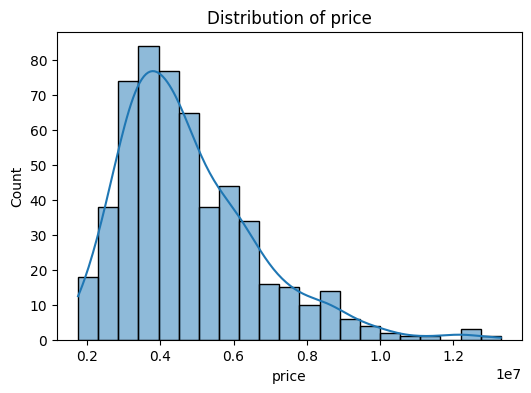

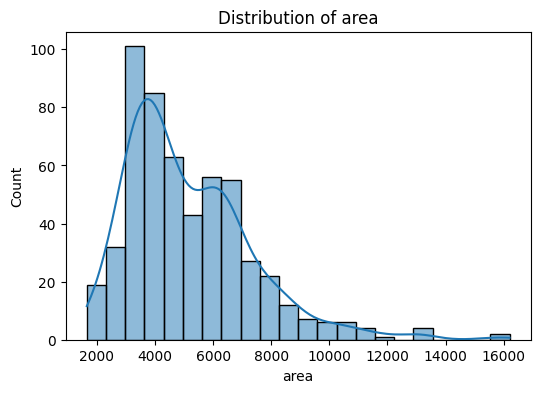

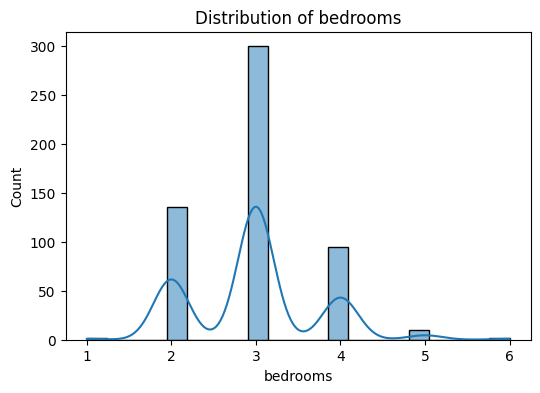

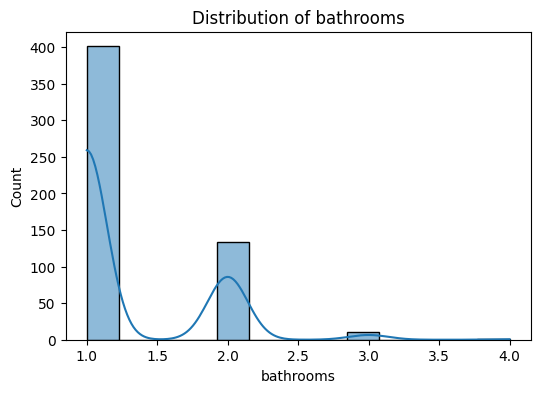

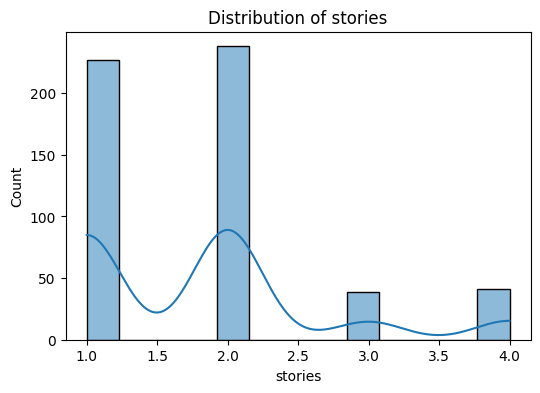

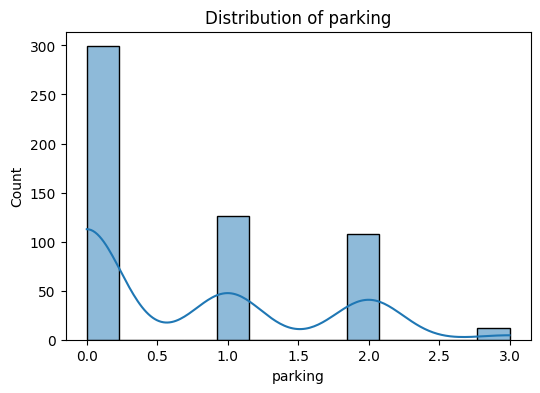

In [139]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(data=df, x=cols,kde = True)
  plt.title(f'Distribution of {cols}')
  plt.show()

In [140]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_encoded = df.copy()
df_encoded['mainroad'] = encoder.fit_transform(df_encoded['mainroad'])
df_encoded['guestroom'] = encoder.fit_transform(df_encoded['guestroom'])
df_encoded['basement'] = encoder.fit_transform(df_encoded['basement'])
df_encoded['hotwaterheating'] = encoder.fit_transform(df_encoded['hotwaterheating'])
df_encoded['airconditioning'] = encoder.fit_transform(df_encoded['airconditioning'])
df_encoded['prefarea'] = encoder.fit_transform(df_encoded['prefarea'])
df_encoded['furnishingstatus'] = encoder.fit_transform(df_encoded['furnishingstatus'])

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [142]:
X = df_encoded.iloc[:, 1:]
y = df_encoded.iloc[:, 0]

In [143]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,2
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,1,0,0,0,0,0,0,2
543,2910,3,1,1,0,0,0,0,0,0,0,0


In [144]:
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [163]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [164]:
from sklearn.metrics import mean_absolute_error

In [165]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [166]:
y_train_pred = lr_model.predict(X_train)

In [167]:
print(mean_absolute_error(y_train, y_train_pred))

771923.2291447549


In [168]:
y_test_pred = lr_model.predict(X_test)

In [169]:
print(mean_absolute_error(y_test, y_test_pred))

787607.5562558771


In [171]:
from sklearn.linear_model import SGDRegressor
lr_sgd = SGDRegressor()
lr_sgd.fit(X_train, y_train)



SGDRegressor()

In [172]:
y_train_pred = lr_model.predict(X_train)

In [173]:
print(mean_absolute_error(y_train, y_train_pred))

771923.2291447549


In [174]:
y_test_pred = lr_model.predict(X_test)

In [175]:
print(mean_absolute_error(y_test, y_test_pred))

787607.5562558771


In [178]:
from sklearn.linear_model import Ridge, Lasso
lr_model = Lasso()
lr_model.fit(X_train, y_train)


Lasso()

In [179]:
y_train_pred = lr_model.predict(X_train)

In [180]:
print(mean_absolute_error(y_train, y_train_pred))

771922.5070400067


In [181]:
y_test_pred = lr_model.predict(X_test)

In [182]:
print(mean_absolute_error(y_test, y_test_pred))

787608.4868270756


In [183]:
lr_model = Ridge()
lr_model.fit(X_train, y_train)

Ridge()